In [67]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import optuna
from src.preprocessing import process_dataframe
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from src._lstm import LSTMRegressor, train_lstm_recursive_val, predict
from src.visualization import plot_forecast
from sklearn.metrics import root_mean_squared_error

In [68]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [69]:
df_train_full = process_dataframe(df_train_full)
df_train = process_dataframe(df_train)
df_val = process_dataframe(df_val)
df_test = process_dataframe(df_test)

In [70]:
target_cols = ['48-1 (0)', '48-1 (1)', '48-1 (2)',
               '48-1 (3)', '48-1 (4)', '48-1 (5)', '48-1 (6)',
               '48-1 (7)', '48-1 (8)', '48-1 (9)', '48-1 (10)', '48-1 (11)']
features_cols = ['day_of_year', 'Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 
                 'day_of_year_cos', 'is_anomaly']
lags_length = 14

df_train_full = df_train_full[features_cols + target_cols]
df_train = df_train[features_cols + target_cols]
df_val = df_val[features_cols + target_cols]
df_test = df_test[features_cols + target_cols]

In [71]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

train_features_scaled = feature_scaler.fit_transform(df_train[features_cols])
train_target_scaled = target_scaler.fit_transform(df_train[target_cols])

train_scaled = np.hstack((train_features_scaled, train_target_scaled))

val_start = df_train[-lags_length:]
df_full_val = pd.concat([val_start, df_val])

val_features_scaled = feature_scaler.transform(df_full_val[features_cols])
val_target_scaled = target_scaler.transform(df_full_val[target_cols])

val_scaled = np.hstack((val_features_scaled, val_target_scaled))

In [72]:
full_feature_scaler = StandardScaler()
full_target_scaler = StandardScaler()

full_train_features_scaled = full_feature_scaler.fit_transform(df_train_full[features_cols])
full_train_target_scaled = full_target_scaler.fit_transform(df_train_full[target_cols])

full_train_scaled = np.hstack((full_train_features_scaled, full_train_target_scaled))

In [73]:
def create_sequences(data, target_start_index, lags_length):
    X, y = [], []
    for i in range(len(data) - lags_length):
        X.append(data[i : i + lags_length])
        y.append(data[i + lags_length, target_start_index:])
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

target_start_index = len(features_cols)

X_train, y_train = create_sequences(train_scaled, target_start_index, lags_length)
X_val, y_val = create_sequences(val_scaled, target_start_index, lags_length)
X_full_train, y_full_train = create_sequences(full_train_scaled, target_start_index, lags_length)

In [74]:
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)
full_train_loader = DataLoader(TensorDataset(X_full_train, y_full_train), batch_size=batch_size)

In [75]:
input_size = train_scaled.shape[1]
output_size = len(target_cols)
criterion = nn.MSELoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def objective(trial):
    hidden_size = trial.suggest_int('hidden_size', 16, 112, step=16)
    num_layers = trial.suggest_int('num_layers', 1, 3)
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    
    model_trial = LSTMRegressor(input_size, hidden_size, num_layers, output_size=output_size).to(device)
    optimizer_trial = torch.optim.Adam(model_trial.parameters(), lr=lr)

    model_trial, val_hist = train_lstm_recursive_val(
        model=model_trial,
        criterion=criterion,
        optimizer=optimizer_trial,
        train_loader=train_loader,
        val_loader=val_loader,
        target_scaler=target_scaler,
        device=device,
        epochs=50,
        max_epochs_no_improvement=10,
        verbose=False
    )
    
    trial.set_user_attr('total_epochs', len(val_hist) - 1)

    best_val_rmse = min(val_hist)
    return best_val_rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

print("Лучшие параметры: ", study.best_params)
print("Количество эпох в лучшем запуске: ", study.best_trial.user_attrs['total_epochs'])

[I 2026-05-28 03:42:02,375] A new study created in memory with name: no-name-7fc8dbe9-b590-4df8-a25b-cb695efb9c64


[I 2026-05-28 03:42:08,691] Trial 0 finished with value: 1.0258355140686035 and parameters: {'hidden_size': 64, 'num_layers': 1, 'lr': 0.00020021343864159356}. Best is trial 0 with value: 1.0258355140686035.


Early stopping on 21 epoch


[I 2026-05-28 03:42:14,608] Trial 1 finished with value: 0.8408694267272949 and parameters: {'hidden_size': 16, 'num_layers': 1, 'lr': 0.0036808846640025666}. Best is trial 1 with value: 0.8408694267272949.


Early stopping on 17 epoch


...

Early stopping on 25 epoch


[I 2026-05-28 03:43:14,806] Trial 7 finished with value: 0.635209858417511 and parameters: {'hidden_size': 32, 'num_layers': 2, 'lr': 0.0005900867867342258}. Best is trial 7 with value: 0.635209858417511.


Early stopping on 32 epoch


[I 2026-05-28 03:43:33,135] Trial 8 finished with value: 2.918799638748169 and parameters: {'hidden_size': 16, 'num_layers': 2, 'lr': 1.0338168416546485e-05}. Best is trial 7 with value: 0.635209858417511.
[I 2026-05-28 03:43:40,362] Trial 9 finished with value: 1.0903750658035278 and parameters: {'hidden_size': 16, 'num_layers': 1, 'lr': 0.0008523510717237376}. Best is trial 7 with value: 0.635209858417511.


Early stopping on 21 epoch
Лучшие параметры:  {'hidden_size': 32, 'num_layers': 2, 'lr': 0.0005900867867342258}
Количество эпох в лучшем запуске:  32


In [76]:
#input_size = full_train_scaled.shape[1]
model = LSTMRegressor(
    input_size=input_size,
    hidden_size=study.best_params['hidden_size'],
    num_layers=study.best_params['num_layers'],
    output_size=output_size
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=study.best_params['lr'])

model, _ = train_lstm_recursive_val(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    device=device,
    epochs=study.best_trial.user_attrs['total_epochs'],
    max_epochs_no_improvement=10,
    verbose=True
)

Epoch 1/32, Train Loss: 0.9670
Epoch 2/32, Train Loss: 0.7735
Epoch 3/32, Train Loss: 0.4300
Epoch 4/32, Train Loss: 0.2638
Epoch 5/32, Train Loss: 0.1860
Epoch 6/32, Train Loss: 0.1402
Epoch 7/32, Train Loss: 0.1082
Epoch 8/32, Train Loss: 0.0836
Epoch 9/32, Train Loss: 0.0649
Epoch 10/32, Train Loss: 0.0564
Epoch 11/32, Train Loss: 0.0612
Epoch 12/32, Train Loss: 0.0544
Epoch 13/32, Train Loss: 0.0421
Epoch 14/32, Train Loss: 0.0342
Epoch 15/32, Train Loss: 0.0314
Epoch 16/32, Train Loss: 0.0303
Epoch 17/32, Train Loss: 0.0283
Epoch 18/32, Train Loss: 0.0275
Epoch 19/32, Train Loss: 0.0286
Epoch 20/32, Train Loss: 0.0238
Epoch 21/32, Train Loss: 0.0244
Epoch 22/32, Train Loss: 0.0217
Epoch 23/32, Train Loss: 0.0240
Epoch 24/32, Train Loss: 0.0200
Epoch 25/32, Train Loss: 0.0232
Epoch 26/32, Train Loss: 0.0198
Epoch 27/32, Train Loss: 0.0225
Epoch 28/32, Train Loss: 0.0202
Epoch 29/32, Train Loss: 0.0231
Epoch 30/32, Train Loss: 0.0180
Epoch 31/32, Train Loss: 0.0172
Epoch 32/32, Trai

Test RMSE: 0.6277
RMSE for 48-1 (0): 2.6471


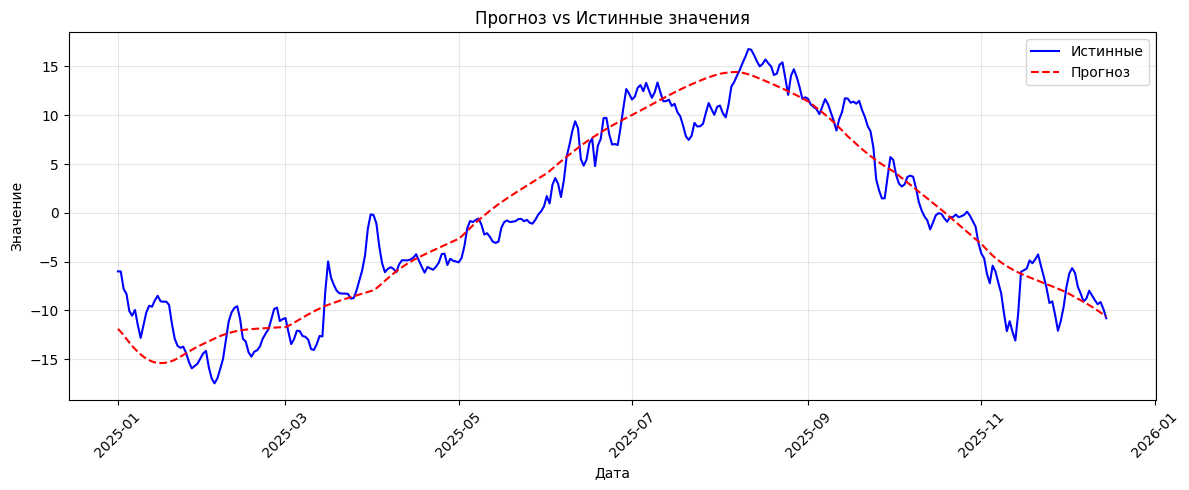

RMSE for 48-1 (1): 1.1385


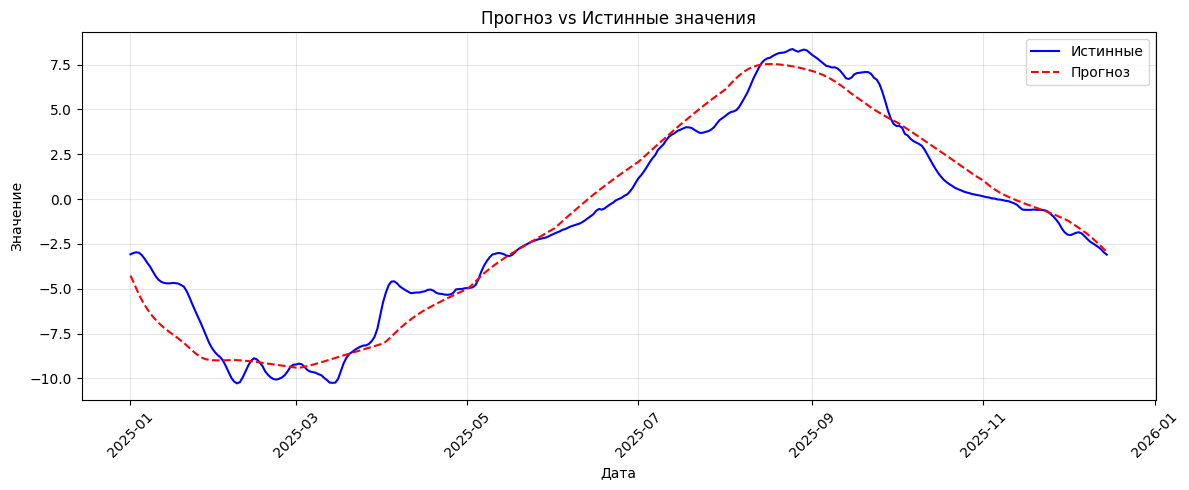

RMSE for 48-1 (2): 0.7357


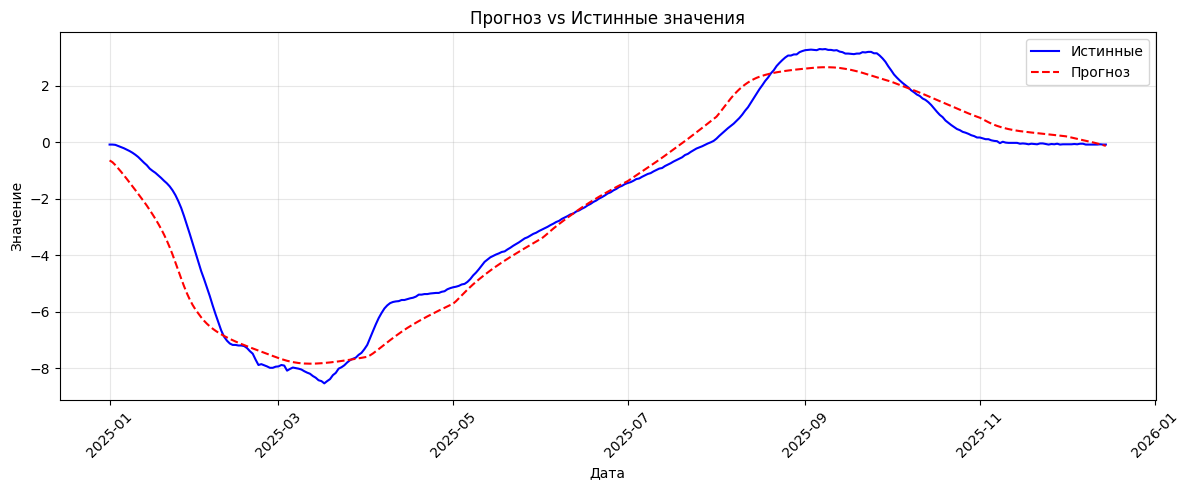

RMSE for 48-1 (3): 0.5472


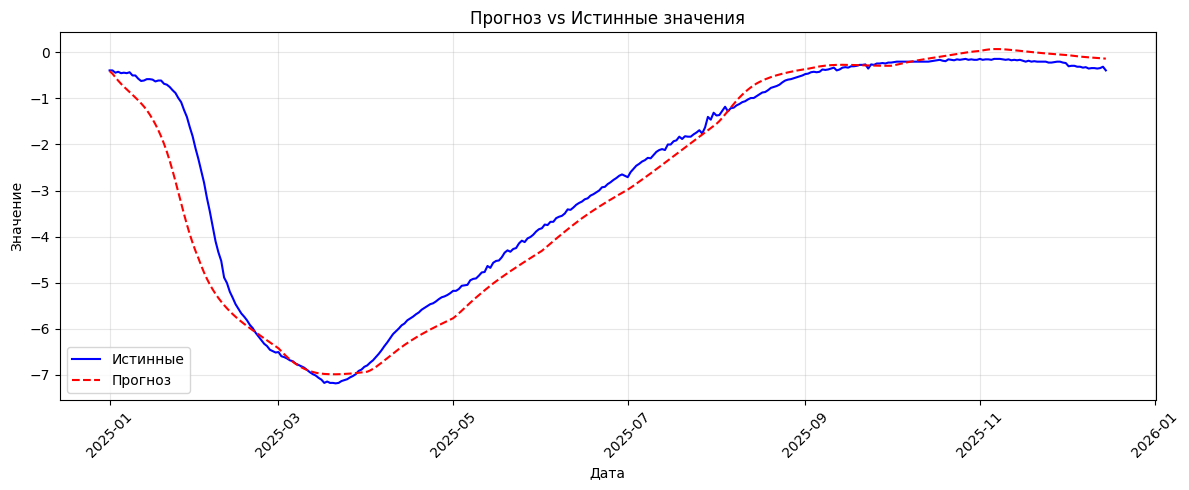

RMSE for 48-1 (4): 0.4157


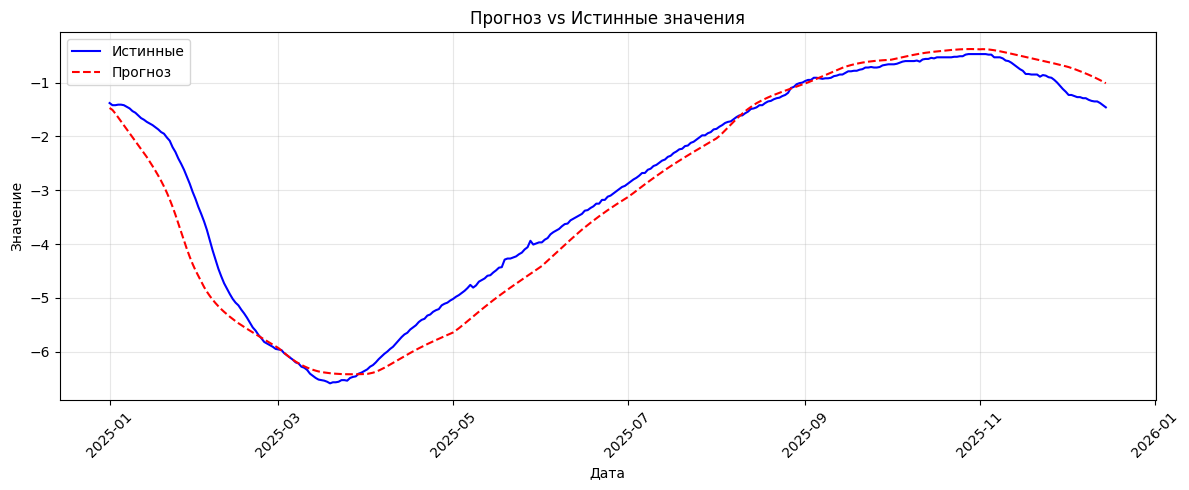

RMSE for 48-1 (5): 0.3840


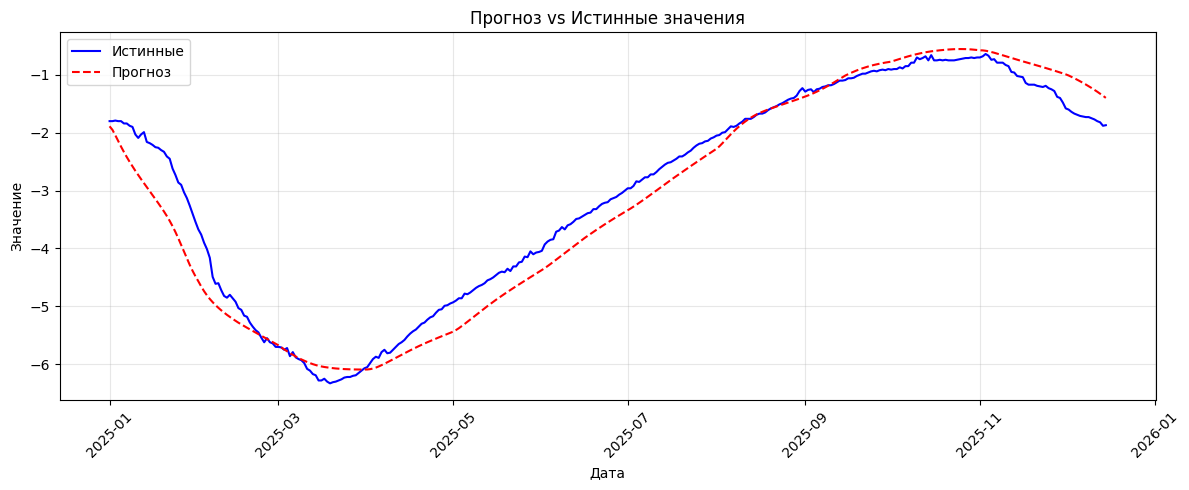

RMSE for 48-1 (6): 0.4064


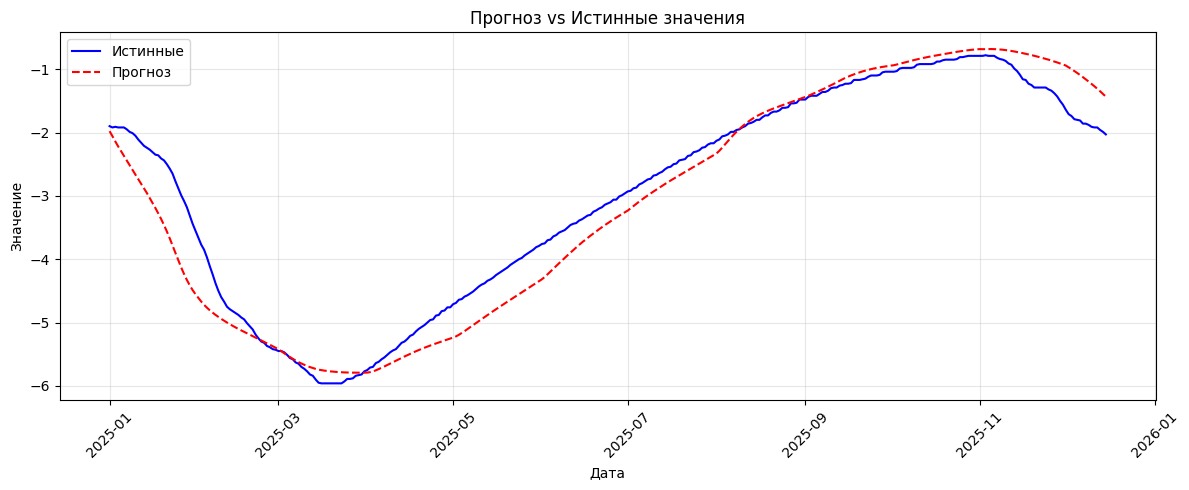

RMSE for 48-1 (7): 0.3568


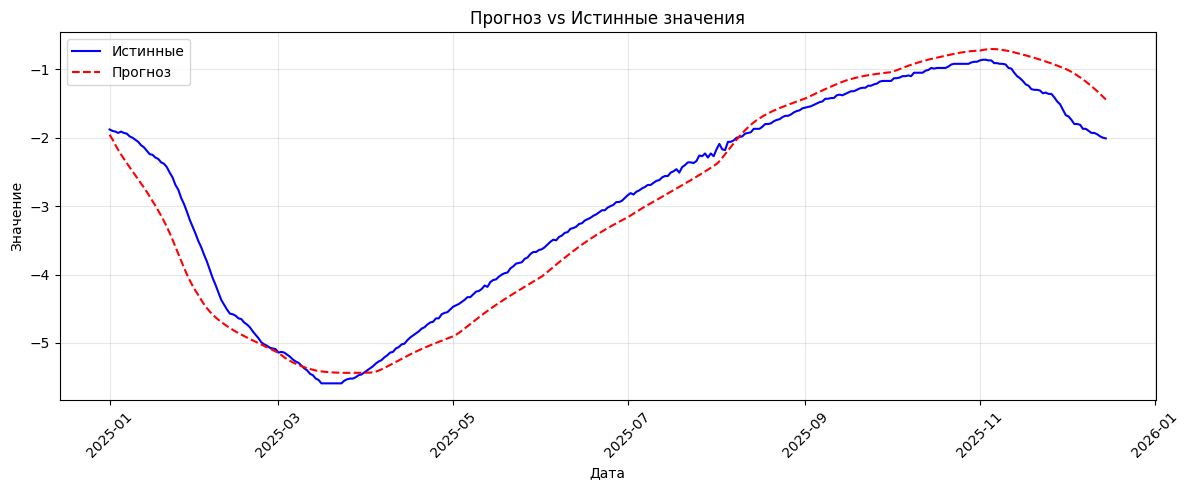

RMSE for 48-1 (8): 0.3055


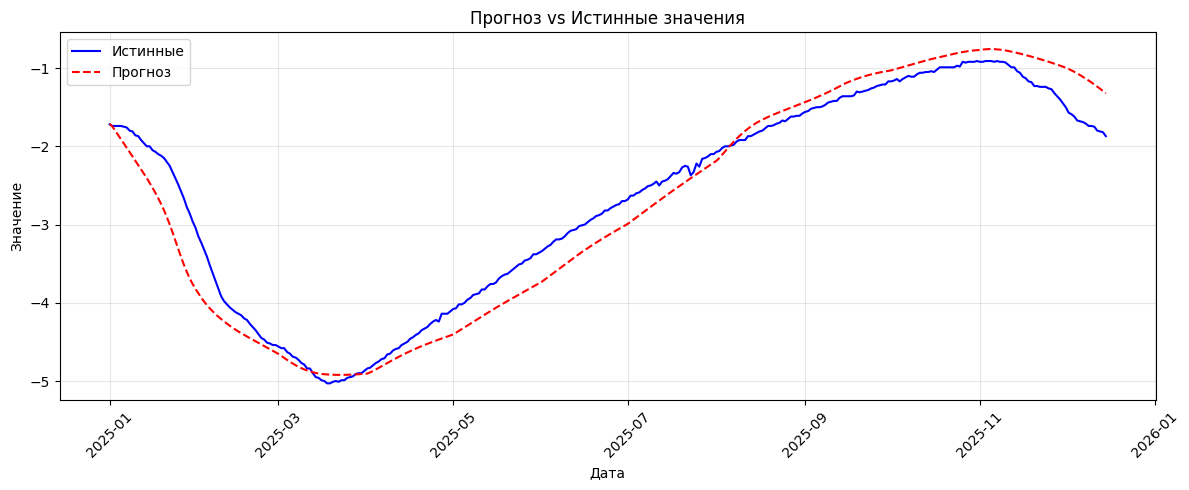

RMSE for 48-1 (9): 0.2380


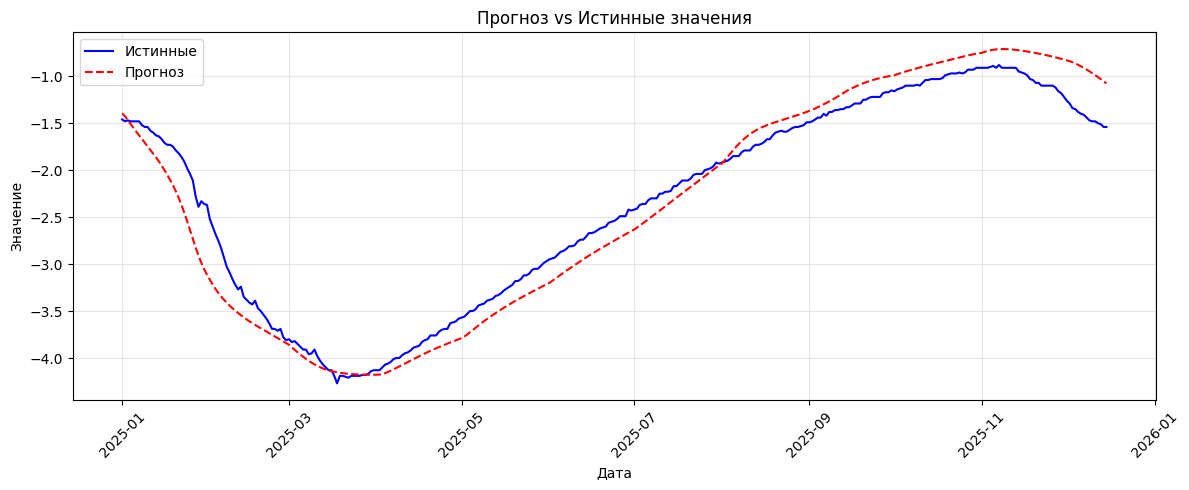

RMSE for 48-1 (10): 0.1622


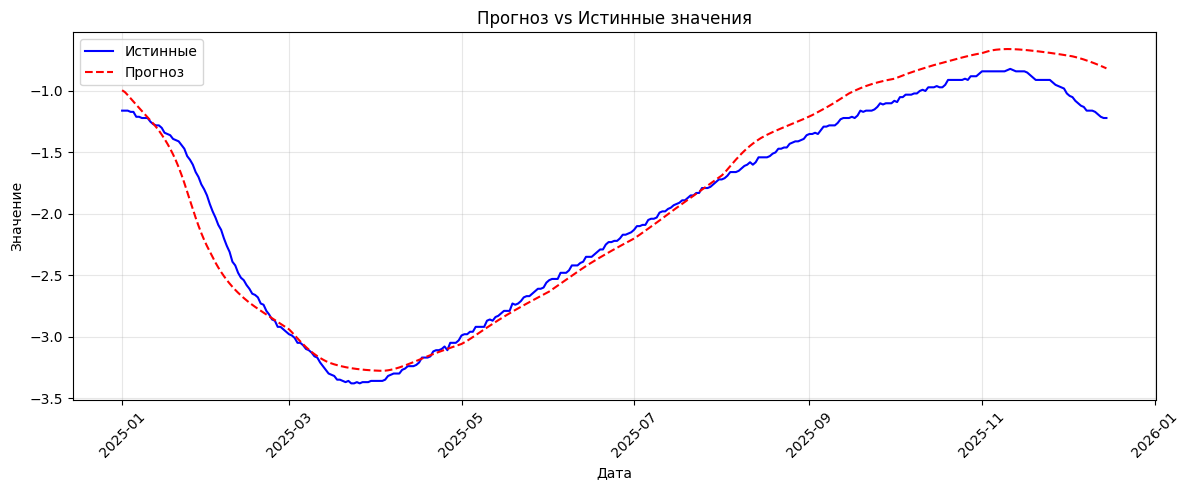

RMSE for 48-1 (11): 0.1955


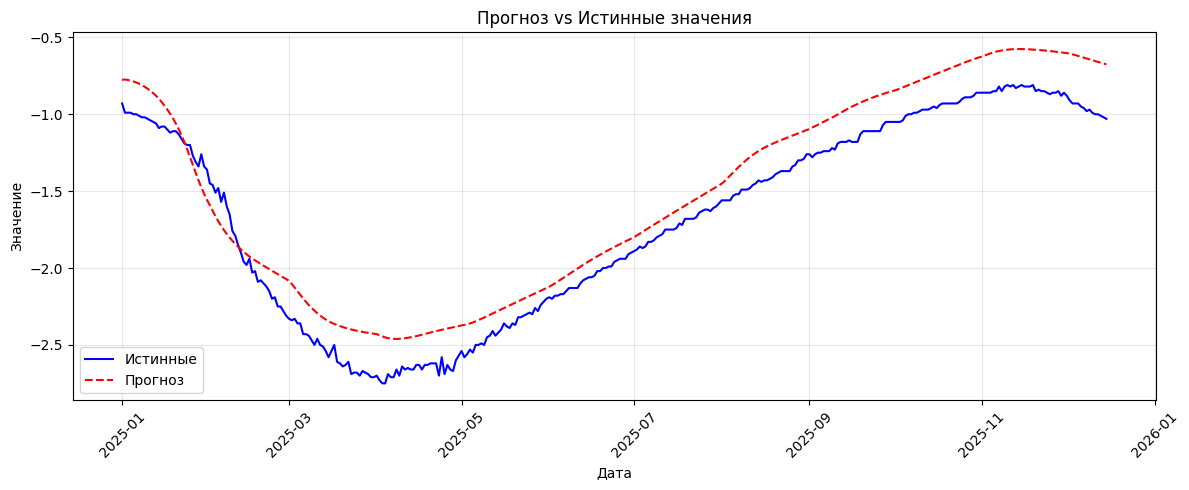

In [77]:
test_start = df_train_full[-lags_length:]

start_features_scaled = feature_scaler.transform(test_start[features_cols])
start_target_scaled = target_scaler.transform(test_start[target_cols])

current_lags = np.hstack((start_features_scaled, start_target_scaled))

future_features_scaled = feature_scaler.transform(df_test[features_cols])

start_lags_tensor = torch.tensor(current_lags, dtype=torch.float32)
future_features_tensor = torch.tensor(future_features_scaled, dtype=torch.float32)

y_pred_scaled = predict(model, start_lags_tensor, future_features_tensor, device=device)

y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_true = df_test[target_cols].values

rmse = root_mean_squared_error(y_true, y_pred)
print(f"Test RMSE: {rmse:.4f}")

rmse_per_depth = root_mean_squared_error(y_true, y_pred, multioutput='raw_values')
for i, col in enumerate(target_cols):
    rmse = rmse_per_depth[i]
    print(f'RMSE for {col}: {rmse:.4f}')
    
    s_true = pd.Series(y_true[:, i], index=df_test.index)
    s_pred = pd.Series(y_pred[:, i], index=df_test.index)
    
    plot_forecast(pd.DataFrame(s_true), pd.DataFrame(s_pred))